# This notebook tracks the amount of memory needed to do the optimisation.  Note that we only run for 1 step each cycle.  Otherwise the time taken will be too long. 

In [1]:
%run -i ~/project/preambles
%run -i ~/project/helper_functions
%run -i ~/project/fitting_functions

In [2]:
# # Global parameters:
number_of_cycles = 1 # how many passes through the training data we go through
number_of_groups = 1 # divide the data set into smaller ones, to make fitting easier.
steps_per_batch = 1
dims = 2  # 2D spatial
head = 0 # how many locations to consider in the real data set.

# for synthetic data
# locations_per_group = 200 # how many locations to observe per group
# number_of_locations = number_of_groups * locations_per_group # total locations
# number_of_simulations = 300 # for synthetic data, how many optimisation to average over
# p =  3 # how many features 

In [3]:
gene_list = [ "Inha", "Inhba", "Inhbb", "Fst", "Esr1", "Esr2", "Pgr", "Ar", "Cyp19a1", 
    "Cyp17a1", "Cyp11a1", "Lhcgr", "Parm1", "Akr1c18", "Fshr", "Star", "Ptgfr", 
    "Sfrp4", "Acvr1", "Acvr2a", "Acvr2b", "Ghr", "Lhb", "Cga"]
# puck_list = ['Puck_230223_01', 'Puck_230406_01', 'Puck_230406_06', 'Puck_230406_08', 
#              'Puck_230517_37', 'Puck_230517_38', 'Puck_230517_39', 'Puck_230913_07', 
#              'Puck_240108_20', 'Puck_240108_24', 'Puck_240108_25', 'Puck_240108_26', 
#              'A0029_047', 'A0029_043', 'Puck_230807_27', 'Puck_240129_36', 'Puck_240129_37', 
#              'A0029_042', 'A0029_036', 'PM104_004', 'Puck_240108_10', 'Puck_240108_11', 
#              'Puck_230807_04', 'Puck_230714_28', 'Puck_230714_23']
# puck_list = 'all'
gene_list = ["Inha", "Esr1"]
puck_list = ['Puck_230517_39'] # the largest puck
adata, X,Y,df, gene_list=load_data(gene_list=gene_list, head=head, puck_list = puck_list)
df

,x,y,Inha,Esr1
TTAGTCCAAGACCA-1-2,2.8425,1.9829,0.000000,0.0
TTTGGTCTCCCTCA-1-2,1.6298,2.7722,0.000000,0.0
CGCGACTGATCCGG-1-2,2.9677,2.0299,0.000000,0.0
ACATGGCGGGTCGA-1-2,1.9708,3.4735,0.000000,0.0
CGGGTCTAGTTTTG-1-2,2.4423,2.3872,0.591154,0.0
...,...,...,...,...
TTCGTACAACGGCA-1-2,2.8560,2.7053,2.440512,0.0
TGTGTGTCAAGGTG-1-2,2.3960,3.4572,0.000000,0.0
TGAGCAATACGAGT-1-2,2.2355,2.3126,0.000000,0.0
GCTGTTCTCGTCGC-1-2,3.0120,1.9951,0.000000,0.0


In [4]:
# def tensor_memory_usage(tensor):
#     # Calculate the memory usage in bytes
#     memory_bytes = tensor.numel() * tensor.element_size()
#     # Convert to MB or GB if needed
#     memory_mb = memory_bytes / (1024 ** 2)  # Convert bytes to megabytes
#     memory_gb = memory_bytes / (1024 ** 3)  # Convert bytes to gigabytes
    
#     return memory_bytes, memory_mb, memory_gb

# tensor_memory_usage(X)

In [5]:
# df.memory_usage().sum()/ (1024 ** 2)

In [6]:
# df["Lhb"].value_counts()

In [7]:
# # code for checking if a gene actually exists.
# gene_name = "Cga"
# matching_genes = [gene for gene in adata.raw.var_names if gene_name in gene]
# if matching_genes:
#     print(f"{gene_name} is found in the following gene names: {matching_genes}")
# else:
#     print(f"{gene_name} is not part of any gene names.")

In [8]:
unique_values = adata.obs["puck"].unique()
counts = adata.obs["puck"].value_counts()

print("Unique values:", list(unique_values))
print("Counts for each unique value:", counts)

Unique values: ['Puck_230517_39']
Counts for each unique value: puck
Puck_230517_39    15907
Name: count, dtype: int64


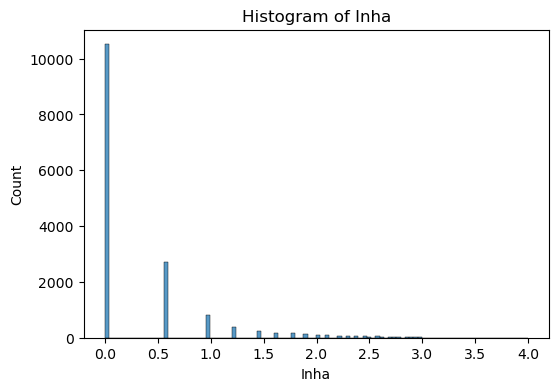

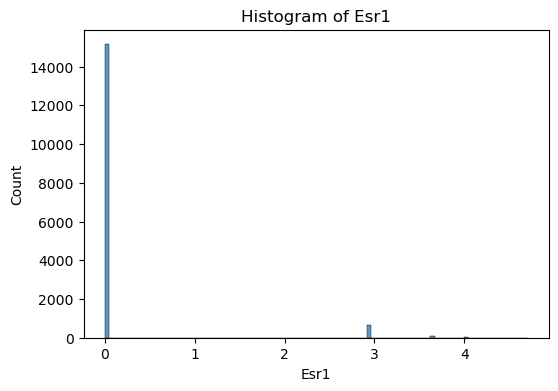

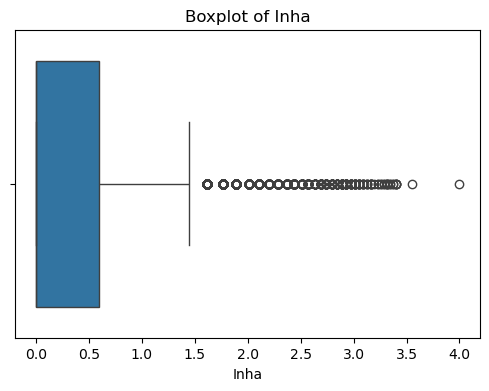

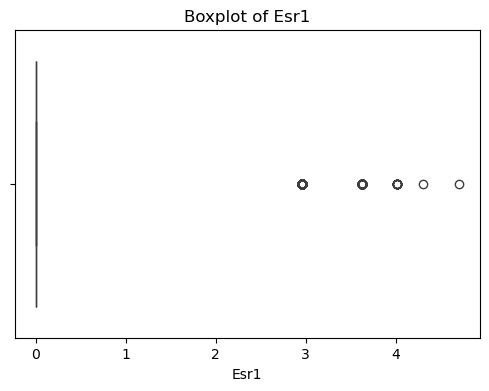

          Inha      Esr1
Inha  1.000000 -0.001987
Esr1 -0.001987  1.000000


In [9]:
### Exploratory Data Analysis
# Plot histograms
for gene in gene_list:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[gene], kde=False, bins=100)
    plt.title(f'Histogram of {gene}')
    plt.show()

# Plot boxplots
for gene in gene_list:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[gene])
    plt.title(f'Boxplot of {gene}')
    plt.show()

# Calculate pairwise Spearman's correlation
spearman_corr = df[gene_list].corr(method='spearman')

# Print the Spearman correlation matrix
print(spearman_corr)

# Assuming spearman_corr is your Spearman correlation matrix
# Set the diagonal to NaN to exclude it from the condition
# np.fill_diagonal(spearman_corr.values, np.nan)

# Filter the off-diagonal values with an absolute value greater than 0.3
off_diagonal_filtered = spearman_corr[(spearman_corr.abs() > 0.3)]

# Get the pairs of features that satisfy the condition
pairs = []
for row in off_diagonal_filtered.index:
    for col in off_diagonal_filtered.columns:
        if row > col:
            if not np.isnan(off_diagonal_filtered.loc[row, col]):
                pairs.append((row, col, off_diagonal_filtered.loc[row, col]))

pairs = sorted(pairs, key=lambda pair: pair[2], reverse=True)

# Print the pairs and their corresponding Spearman correlation values
for pair in pairs:
    print(f"Pair: {pair[0]} and {pair[1]}, Correlation: {pair[2]:.3g}")

In [10]:
# # plot the spatial distribution on the pucks
# # Create a folder to save the figures
# output_folder = "puck_spatial_plots"
# if not os.path.exists(output_folder):
#     os.makedirs(output_folder)

# # Get spatial coordinates
# spatial_coords = adata.obsm["spatial"]

# # Loop through each puck and plot
# puck_labels = adata.obs["puck"].unique()

# for puck in puck_labels:
#     puck_mask = adata.obs["puck"] == puck
#     puck_coords = spatial_coords[puck_mask]
    
#     plt.figure(figsize=(6, 6))
#     plt.scatter(puck_coords[:, 0], puck_coords[:, 1], s=10, alpha=0.6)
#     plt.title(f'Spatial distribution for puck {puck}')
#     plt.xlabel('X coordinate')
#     plt.ylabel('Y coordinate')
#     plt.gca().invert_yaxis()  # Invert the y-axis if necessary for correct orientation
    
#     # Save the plot
#     save_path = os.path.join(output_folder, f"puck_{puck}_spatial_plot.png")
#     plt.savefig(save_path)
#     plt.close()  # Close the figure to avoid display


### The memory tracker

In [11]:
# this block runs the loading and the optimisation steps 
def fitting_codes(head):
    adata, X,Y,df=load_data(gene_list=gene_list, head=head, puck_list = puck_list)
    estimated_params_df = pd.DataFrame()
    distance_K_df = pd.DataFrame()

    torch.autograd.set_detect_anomaly(True)
    optimized_marginal_params = optimize_marginal_parameters(X, Y, number_of_groups,  number_of_cycles, steps_per_batch)
    # print(optimized_marginal_params)
    alpha_matrix, nu_matrix, sigma_matrix = optimize_cross_parameters(optimized_marginal_params,X,Y,number_of_groups,number_of_cycles,steps_per_batch)
    # estimated_K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
    # distance_K = torch.norm(true_K - estimated_K)**2 / torch.norm(true_K)**2
    # distance_K_df = pd.concat([distance_K_df, pd.DataFrame([distance_K.item()])] ,ignore_index=True)
    estimated_params_df = pd.concat([estimated_params_df, store_as_df(alpha_matrix, nu_matrix, sigma_matrix) ], ignore_index=True)

    return estimated_params_df

In [12]:
# Memory tracking function
import tracemalloc
import time
def track_memory(head):
    # Start memory tracking
    tracemalloc.start()
    
    # Run the actual code that you want to track memory for
    fitting_codes(head)
    
    # Get the memory peak usage
    current, peak = tracemalloc.get_traced_memory()
    
    # Stop memory tracking
    tracemalloc.stop()
    
    # Return the peak memory usage in GB
    return peak / (1024 **3)

# List of different 'n' values to test
# heads = [1000, 2000, 5000, 10000, 12000, 15000]
# To store the memory usage results
memory_usages = []

def main(head, memory_usages):
    start_time = time.time()
    print(time.ctime(start_time))
    print(f"{head} locations fitting has started...")
    memory_used = track_memory(head)
    print(f"{head} locations require {memory_used} GB memory")
    memory_usages.append(memory_used)
    end_time = time.time()
    print(time.ctime(end_time))
    elapsed_time =(end_time - start_time)/3600
    print(f"Time taken: {elapsed_time:.6f} hours")
    return memory_usages

In [13]:
memory_usages = []
memory_usages = main(11*2000, memory_usages)

Fri Oct  4 17:24:14 2024
22000 locations fitting has started...


22000 locations require 24.048062403686345 GB memory
Fri Oct  4 17:59:06 2024
Time taken: 0.581067 hours


### Memory Profiling ends

### At this stage, we have obtained our data.

In [14]:
# estimated_params_df = pd.DataFrame()
# distance_K_df = pd.DataFrame()
# for _ in range(1):
#     try:
#         torch.autograd.set_detect_anomaly(True)
#         optimized_marginal_params = optimize_marginal_parameters(X, Y, number_of_groups,  number_of_cycles, steps_per_batch)
#         print(optimized_marginal_params)
#         alpha_matrix, nu_matrix, sigma_matrix = optimize_cross_parameters(optimized_marginal_params,X,Y,number_of_groups,number_of_cycles,steps_per_batch)
#         # estimated_K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
#         # distance_K = torch.norm(true_K - estimated_K)**2 / torch.norm(true_K)**2
#         # distance_K_df = pd.concat([distance_K_df, pd.DataFrame([distance_K.item()])] ,ignore_index=True)
#         estimated_params_df = pd.concat([estimated_params_df, store_as_df(alpha_matrix, nu_matrix, sigma_matrix) ], ignore_index=True)
#     except Exception as e:
#         print(e)
#         continue
# estimated_params_df

In [15]:
# estimated_params_df = pd.DataFrame()
# distance_K_df = pd.DataFrame()
# for _ in range(number_of_simulations):
#     try:
#         optimized_marginal_params = optimize_marginal_parameters(X, Y, number_of_groups,  number_of_cycles, steps_per_batch)
#         alpha_matrix, nu_matrix, sigma_matrix = optimize_cross_parameters(optimized_marginal_params,X,Y,number_of_groups,number_of_cycles,steps_per_batch)
#         estimated_K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
#         estimated_params_df = pd.concat([estimated_params_df, store_as_df(alpha_matrix, nu_matrix, sigma_matrix) ], ignore_index=True)
#     except Exception as e:
#         print(e)
#         continue
# estimated_params_df

In [16]:
# import matplotlib.pyplot as plt
# import math

# # Get the list of columns
# columns = estimated_params_df.columns

# # Calculate the number of rows and columns for subplots
# n_params = len(columns)
# n_cols = 3  # Fixed number of columns for layout
# n_rows = math.ceil(n_params / n_cols)  # Calculate required rows based on the number of parameters

# plt.figure(figsize=(15, 2.5 * n_rows))  # Adjust height based on number of rows
# for i, col in enumerate(columns):
#     plt.subplot(n_rows, n_cols, i + 1)
    
#     # Plot the histogram of estimates
#     plt.hist(estimated_params_df[col], bins=30, color='skyblue', edgecolor='black')
    
#     # Plot the vertical line for the true value
#     # plt.axvline(x=ground_truth_df[col].iloc[0], color='red', linestyle='--', linewidth=2)
    
#     plt.title(f'{col} Distribution')
#     plt.xlabel(f'{col}')
#     plt.ylabel('Frequency')
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

Save the computed parameters

In [17]:
# # Concatenate the two DataFrames along the columns (axis=1)
# # combined_df = pd.concat([estimated_params_df, distance_K_df], axis=1)
# # # Define the file path using f-string and expand the home directory
# file_path = os.path.expanduser(f'~/project/python_processed_data/estimated_parameters_4.csv')
# # # Save the combined DataFrame to a CSV file
# # combined_df.to_csv(file_path, index=False)
# # combined_df
# estimated_params_df.to_csv(file_path, index=False)